# A portfolio of merchants

Notebook 15 prices a single merchant, and there the price card barely beats a flat rate: with one book, a flat price can be tuned to that book's risk and gets most of the way there.

A coverage platform does not serve one merchant. It serves **thousands, with very different return rates** — an electronics seller at 8% and a fashion brand at 45% sit in the same programme. That changes the answer, because a single platform-wide price cannot be tuned to anyone:

- **Low-return merchants are overcharged.** Their shoppers see a price built for someone else's risk and decline.
- **High-return merchants are undercharged.** The platform pays out more than it collects on them.

The price card has neither problem, because it prices the *order*, not the merchant. Same rule everywhere, no per-merchant tuning to maintain.

This notebook simulates **4,000 merchants** and compares three policies.

**Setup.** Merchant return rates are drawn around a 25% centre and clipped to a plausible 5–60% range, then bucketed so the simulation stays fast. Each merchant's order book is the validation set with its calibrated probabilities shifted to that merchant's base rate.

In [1]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.special import expit, logit
from src.data import INTERIM, ROOT

FIGURES = ROOT / "figures"; FIGURES.mkdir(exist_ok=True)
RETURN_COST, MARKUP = 8.0, 0.45
MORAL_HAZARD, ADVERSE_SELECTION = 0.10, 2.0
ANCHOR_PRICE, ANCHOR_ATTACH, PRICE_SLOPE = 5.0, 0.35, 0.15
N_MERCHANTS, BOOK = 4000, 100_000_000
SURFACE, GRID, INK, MUTED, BASE = "#fcfcfb", "#e1e0d9", "#0b0b0b", "#52514e", "#c3c2b7"

p = pd.read_parquet(INTERIM / "predictions.parquet")
r_base = np.clip(p.pred.values, 1e-6, 1 - 1e-6)

rng = np.random.default_rng(0)
rates = np.clip(rng.normal(0.25, 0.10, N_MERCHANTS), 0.05, 0.60).round(2)
buckets = pd.Series(rates).value_counts().sort_index()
print(f"{N_MERCHANTS} merchants, {len(buckets)} distinct return rates "
      f"from {buckets.index.min():.0%} to {buckets.index.max():.0%}")
print(f"portfolio mean return rate {rates.mean():.1%}")

4000 merchants, 53 distinct return rates from 5% to 58%
portfolio mean return rate 24.9%


**Shift each merchant's risk distribution.** A logit offset moves the base rate while preserving the model's ranking, so every merchant inherits the same discriminative power at its own prevalence.

In [2]:
def shift_to(target):
    d = brentq(lambda delta: expit(logit(r_base) + delta).mean() - target, -30, 30)
    return expit(logit(r_base) + d)

merchants = {}
for rate, weight in buckets.items():
    r = shift_to(rate)
    r_eff = r + MORAL_HAZARD * (1 - r)
    merchants[rate] = {"weight": int(weight), "r": r, "claim": r_eff * RETURN_COST}

all_r = np.concatenate([m["r"] for m in merchants.values()])
all_w = np.concatenate([np.full(len(m["r"]), m["weight"]) for m in merchants.values()]).astype(float)
all_claim = np.concatenate([m["claim"] for m in merchants.values()])
pooled_mean = float(np.average(all_r, weights=all_w))
len(all_r), round(pooled_mean, 4)

(6040198, 0.2493)

**One demand model for the whole portfolio**, anchored so 35% of shoppers buy at $5. Merchants differ only in their risk distribution, which isolates the effect of return-rate heterogeneity.

In [3]:
INTERCEPT = brentq(
    lambda a: np.average(expit(a - PRICE_SLOPE * ANCHOR_PRICE + ADVERSE_SELECTION * (all_r - pooled_mean)),
                         weights=all_w) - ANCHOR_ATTACH, -40, 40)

def outcome(price, r, claim, w=None):
    price = np.broadcast_to(np.asarray(price, dtype=float), r.shape)
    t = expit(INTERCEPT - PRICE_SLOPE * price + ADVERSE_SELECTION * (r - pooled_mean))
    kw = {} if w is None else {"weights": w}
    rev = float(np.average(t * price, **kw))
    clm = float(np.average(t * claim, **kw))
    att = float(np.average(t, **kw))
    return {"attach": att, "revenue": rev, "claims": clm, "profit": rev - clm,
            "markup": (rev / clm - 1) if clm > 0 else np.nan}

## Three policies

**Three ways to price the same portfolio.** (a) and (b) both need a solver, because a flat price only reaches a markup target through the demand curve — who buys at that price determines what is collected and what is claimed. (c) needs no solver at all: `price = 1.45 x expected claim` earns 45% on every order by construction. That asymmetry is the practical argument. The flat policies require tuning that has to be maintained per merchant as their return behaviour drifts; the card is one rule that self-adjusts.

In [4]:
# (a) one platform-wide flat price, solved for a 45% markup across the whole portfolio
platform_flat = brentq(
    lambda price: outcome(price, all_r, all_claim, all_w)["markup"] - MARKUP, 0.51, 400.0)

# (b) per-merchant flat prices, each solved for 45% on that merchant alone
per_merchant = {}
for rate, m in merchants.items():
    per_merchant[rate] = brentq(
        lambda price: outcome(price, m["r"], m["claim"])["markup"] - MARKUP, 0.51, 400.0)

print(f"(a) one platform-wide flat price: ${platform_flat:.2f}")
print(f"(b) per-merchant flat prices range ${min(per_merchant.values()):.2f} "
      f"to ${max(per_merchant.values()):.2f}")
print(f"(c) price card: 1.45 x expected claim, no tuning required")

(a) one platform-wide flat price: $4.99
(b) per-merchant flat prices range $1.85 to $8.34
(c) price card: 1.45 x expected claim, no tuning required


**Score every merchant under all three policies.** Each merchant's book is evaluated separately so per-merchant outcomes can be inspected, then aggregated with merchant counts as weights. `merchants_losing_money` is the share whose claims exceed their coverage revenue outright — a number that only exists because one price is being asked to serve very different risk profiles.

In [5]:
rows = []
for rate, m in merchants.items():
    r, claim, w = m["r"], m["claim"], m["weight"]
    a = outcome(platform_flat, r, claim)
    b = outcome(per_merchant[rate], r, claim)
    c = outcome((1 + MARKUP) * claim, r, claim)
    for name, o in [("platform flat", a), ("per-merchant flat", b), ("price card", c)]:
        rows.append({"rate": rate, "weight": w, "policy": name, **o})
detail = pd.DataFrame(rows)

portfolio = (detail.groupby("policy")
             .apply(lambda d: pd.Series({
                 "attach": np.average(d.attach, weights=d.weight),
                 "revenue": np.average(d.revenue, weights=d.weight),
                 "profit": np.average(d.profit, weights=d.weight),
                 "markup": np.average(d.revenue, weights=d.weight) / np.average(d.claims, weights=d.weight) - 1,
                 "merchants_losing_money": float(np.average(d.profit < 0, weights=d.weight))}))
             .reindex(["platform flat", "per-merchant flat", "price card"]))
orders = BOOK / portfolio.loc["platform flat", "revenue"]
portfolio["revenue_100M"] = (portfolio.revenue * orders).round(0)
portfolio["contribution"] = (portfolio.profit * orders).round(0)
portfolio.round(4)

,attach,revenue,profit,markup,merchants_losing_money,revenue_100M,contribution
policy,,,,,,,
platform flat,0.3503,1.7484,0.5426,0.45,0.0118,100000000.0,31034483.0
per-merchant flat,0.3546,1.7201,0.5338,0.45,0.0000,98383679.0,30532866.0
price card,0.3853,1.5467,0.4800,0.45,0.0000,88465053.0,27454672.0


## Where the platform-wide rate goes wrong

**The spread is the point.** Under one platform-wide price the markup earned per merchant has a standard deviation of roughly 0.72 and runs from negative to nearly +283%; under the price card it is 45% on every single merchant, with zero variance. A platform-wide average of 45% hides the fact that almost no individual merchant is actually at 45%.

In [6]:
wide = detail.pivot_table(index="rate", columns="policy", values="markup")
wide["orders_share"] = buckets / buckets.sum()
print("markup earned per merchant (target 45%):")
print(wide[["platform flat", "price card"]].describe().round(3).to_string())
print()
losers = wide[wide["platform flat"] < MARKUP]
print(f"merchants earning below the 45% target under one platform-wide price: "
      f"{float(buckets[losers.index].sum()) / N_MERCHANTS:.0%}")
wide.head(12).round(3)

markup earned per merchant (target 45%):
policy  platform flat  price card
count          53.000       53.00
mean            0.554        0.45
std             0.721        0.00
min            -0.111        0.45
25%             0.038        0.45
50%             0.275        0.45
75%             0.805        0.45
max             2.830        0.45

merchants earning below the 45% target under one platform-wide price: 47%


policy,per-merchant flat,platform flat,price card,orders_share
rate,,,,
0.05,0.45,2.830,0.45,0.023
0.06,0.45,2.517,0.45,0.010
0.07,0.45,2.249,0.45,0.007
0.08,0.45,2.018,0.45,0.010
0.09,0.45,1.818,0.45,0.009
0.10,0.45,1.644,0.45,0.014
0.11,0.45,1.491,0.45,0.014
0.12,0.45,1.357,0.45,0.018
0.13,0.45,1.238,0.45,0.024


**Two series, so a legend is required**, and each line is also distinguishable by shape: the flat-price curve sweeps steeply down through the target while the price card is a horizontal line sitting exactly on it. The horizontal reference marks the 45% goal.

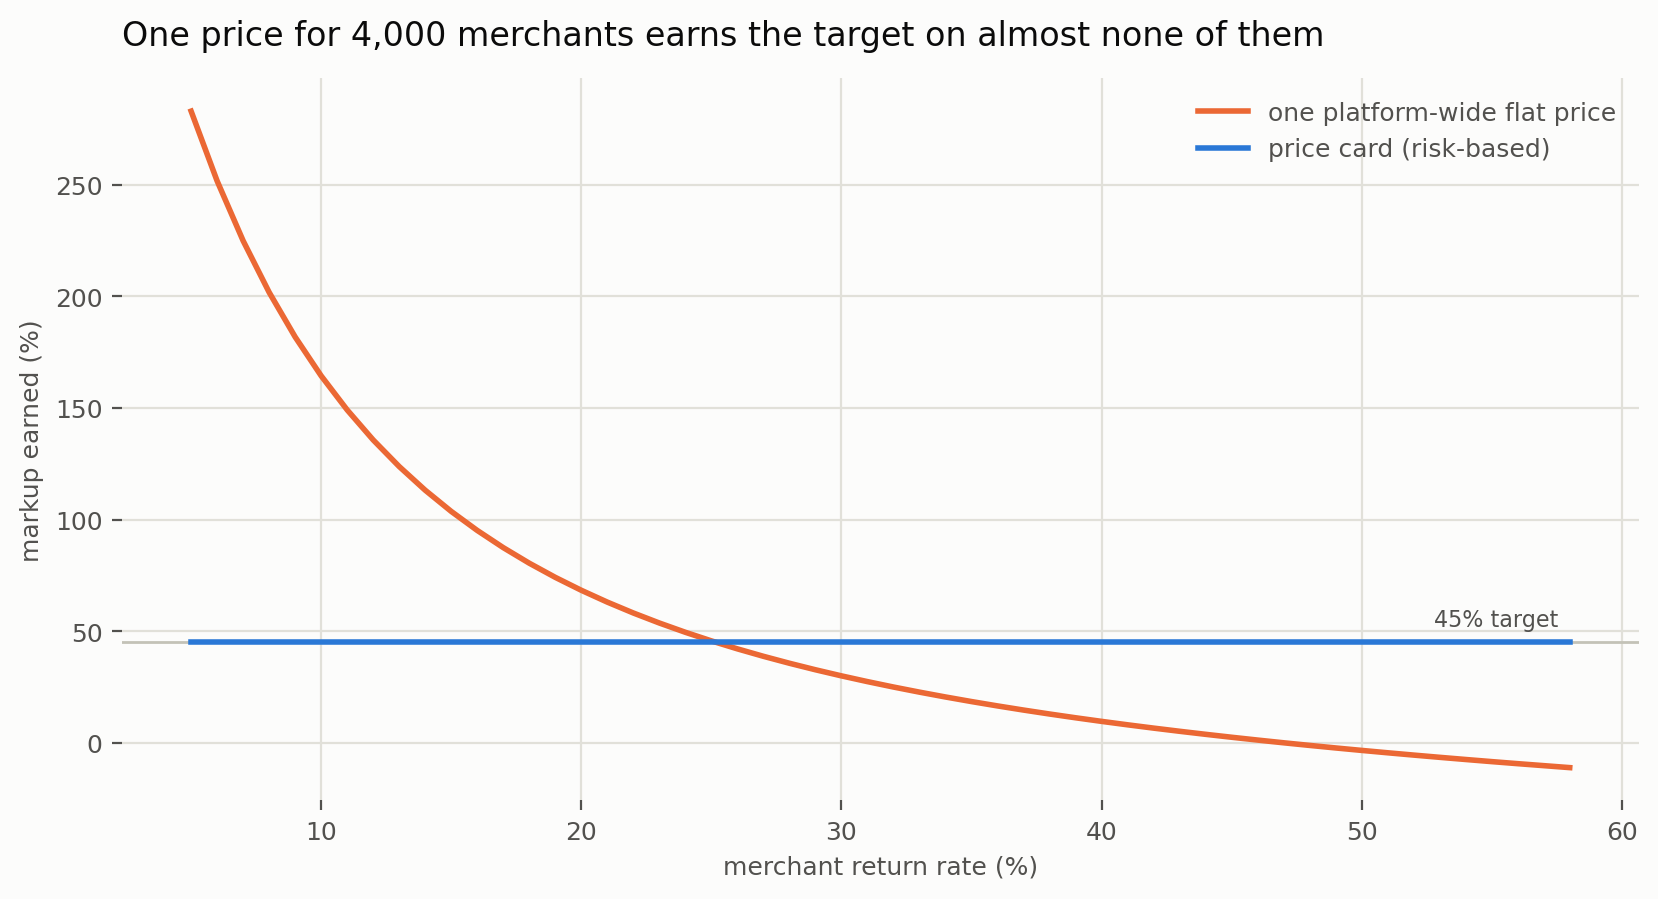

In [7]:
fig, ax = plt.subplots(figsize=(8.4, 4.6), dpi=200)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
ax.plot(wide.index * 100, wide["platform flat"] * 100, color="#eb6834", linewidth=2,
        zorder=3, label="one platform-wide flat price")
ax.plot(wide.index * 100, wide["price card"] * 100, color="#2a78d6", linewidth=2,
        zorder=4, label="price card (risk-based)")
ax.axhline(MARKUP * 100, color=BASE, linewidth=1, zorder=2)
ax.annotate("45% target", (wide.index.max() * 100, MARKUP * 100), xytext=(-4, 6),
            textcoords="offset points", color=MUTED, fontsize=8, ha="right")
ax.grid(True, color=GRID, linewidth=0.8, linestyle="-", zorder=1)
ax.set_axisbelow(True)
for s in ax.spines.values(): s.set_visible(False)
ax.set_xlabel("merchant return rate (%)", color=MUTED, fontsize=9)
ax.set_ylabel("markup earned (%)", color=MUTED, fontsize=9)
ax.set_title("One price for 4,000 merchants earns the target on almost none of them",
             color=INK, fontsize=12, pad=12, loc="left")
ax.tick_params(colors=MUTED, labelsize=9)
ax.legend(loc="upper right", frameon=False, fontsize=9, labelcolor=MUTED)
fig.tight_layout()
fig.savefig(FIGURES / "portfolio_markup.png", facecolor=SURFACE, bbox_inches="tight")
plt.show()

**Persist the portfolio result** with the parameters that produced it — merchant count, markup target, return cost, and the solved prices. Saving the assumptions beside the numbers means a later reader can tell which figures are measured and which follow from the demand curve.

In [8]:
(INTERIM / "portfolio.json").write_text(json.dumps({
    "n_merchants": N_MERCHANTS, "markup_target": MARKUP, "return_cost": RETURN_COST,
    "platform_flat_price": platform_flat,
    "per_merchant_price_range": [min(per_merchant.values()), max(per_merchant.values())],
    "portfolio": portfolio.reset_index().to_dict(orient="records")}, indent=2, default=float))
print("saved")

saved
